In [1]:
# Import
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
import h5py
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
%matplotlib inline
import ecg_plot, pandas as pd
import sys, glob, h5py
import ecgprep
import os

# helper function
def exists(path):
    val = os.path.exists(path)
    if val:
        print(f'{path} already exits. Using cached. Delete it manually to recieve it again!')
    return val

The data is already in HDF5 (H5) format, hence the following is not needed:

```
##################################
# 3. Generate train
#if not exists('2-soa-model-ecg/exams_part0.hdf5'):
#    !python ../ecg-preprocessing/generate_h5.py --new_freq 400 --new_len 4096 --remove_baseline --remove_powerline 60 ../codesubset/train/RECORDS.txt exams_part0.hdf5
##################################
```

In [2]:
!pwd

/mimer/NOBACKUP/groups/naiss2024-5-153/Aditya/2-soa-ecg-model


## Description
The CODE-15% dataset is a part of the greater dataset, or the full dataset CODE. The full dataset has ECG exams of roughly 1.56M patients, which will be the future exploration of this thesis, which is large-scale distributed FL. CODE-15%, as the name suggests, is the 15% chunk of the full dataset, corresponding to ECG exams of around 233K patients. 

The dataset of CODE-15% is split across multiple zip files (17 of them), and each zip file is around 2.7GB (https://zenodo.org/records/4916206). Each zip file contains 20K training examples. For now, we focus on 4 of them.

For a very basic FL scenario, we now assume that each zip file represents a client, in a hypothetical FL training setup. They want to train a state-of-the-art model that conducts age prediction based on the ECG exams, and some other features (e.g. if the patient has been tested positive for certain health conditions).

## The process:
- Here, it is assumed that the data is already preprocessed.
- 4 clients are initially decided to be created, each having 20K training examples (one zip file = one client).
- We run the train function that the SOA age predictor model has, and we provide two paths:
   - \$H5PATH - the path to the ECG exam data
   - \$CSVPATH - the path of the CSV, that contains the patient info (which are additional features that are part of the model's prediction task e.g. isMale, death, and other collected metrics). It is also a matching file for knowing which patient's ECG exam is located in which ZIP file.
- The train-valid split: 20K training examples per client -- [ 16K training, 4K validation ] $\times$ 4 clients

In [12]:
%%time
PATH_TO_CSV = './data/code15-12l/exams.csv'
PATH_TO_H5 = './data/code15-12l/exams_part0.hdf5'
subsets = glob.glob('data/code15-12l/*.hdf5')
subsets

CPU times: user 266 μs, sys: 588 μs, total: 854 μs
Wall time: 1.06 ms


['data/code15-12l/exams_part6.hdf5',
 'data/code15-12l/exams_part8.hdf5',
 'data/code15-12l/exams_part7.hdf5',
 'data/code15-12l/exams_part1.hdf5',
 'data/code15-12l/exams_part12.hdf5',
 'data/code15-12l/exams_part15.hdf5',
 'data/code15-12l/exams_part16.hdf5',
 'data/code15-12l/exams_part10.hdf5',
 'data/code15-12l/exams_part0.hdf5',
 'data/code15-12l/exams_part2.hdf5',
 'data/code15-12l/exams_part3.hdf5',
 'data/code15-12l/exams_part11.hdf5',
 'data/code15-12l/exams_part4.hdf5',
 'data/code15-12l/exams_part13.hdf5',
 'data/code15-12l/exams_part5.hdf5',
 'data/code15-12l/exams_part9.hdf5',
 'data/code15-12l/exams_part14.hdf5']

In [47]:
%%time
traces_ids = np.zeros(len(subsets)*20001)
layout = h5py.VirtualLayout(shape=(len(subsets)*20001, 4096, 12), dtype='float32')
prev = 0

for i, part in enumerate(subsets):
    f = h5py.File(part, 'r')
    ecgchunk = torch.tensor(f['tracings'][()], dtype=torch.float32)
    idchunk = np.array(f['exam_id'])
    vsource = h5py.VirtualSource(part, "tracings", shape=tuple(ecgchunk.size()))
    layout[i*prev:(i+1)*ecgchunk.size(dim=0)] = vsource
    traces_ids[i*prev:(i+1)*ecgchunk.size(dim=0)] = idchunk
    prev = int(ecgchunk.size(dim=0))
    print("filled values from idx ", i*prev, "to", (i+1)*ecgchunk.size(dim=0))
    print(traces_ids.shape)
    print("Done! At number --", i)

filled values from idx  0 to 20001
(340017,)
Done! At number -- 0
filled values from idx  20001 to 40002
(340017,)
Done! At number -- 1
filled values from idx  40002 to 60003
(340017,)
Done! At number -- 2
filled values from idx  60003 to 80004
(340017,)
Done! At number -- 3
filled values from idx  80004 to 100005
(340017,)
Done! At number -- 4
filled values from idx  100005 to 120006
(340017,)
Done! At number -- 5
filled values from idx  120006 to 140007
(340017,)
Done! At number -- 6
filled values from idx  140007 to 160008
(340017,)
Done! At number -- 7
filled values from idx  160008 to 180009
(340017,)
Done! At number -- 8
filled values from idx  180009 to 200010
(340017,)
Done! At number -- 9
filled values from idx  200010 to 220011
(340017,)
Done! At number -- 10
filled values from idx  220011 to 240012
(340017,)
Done! At number -- 11
filled values from idx  240012 to 260013
(340017,)
Done! At number -- 12
filled values from idx  260013 to 280014
(340017,)
Done! At number -- 13
f

In [48]:
with h5py.File("fullCODE15.h5", "w") as f:
    f.create_virtual_dataset("tracings", layout, fillvalue=-1)

In [60]:
with h5py.File("fullCODE15.h5", "r") as f:
    print("\nVDS Shape: ", f["tracings"].shape)


VDS Shape:  (340017, 4096, 12)


In [50]:
df = pd.read_csv(PATH_TO_CSV)
df

In [59]:
#filtered_df = [i in traces_ids for i in df['exam_id']]
#code15df = df.loc[filtered_df]
#code15df.to_csv('../1-starter-ecg-model/data/examscode15.csv')

In [62]:
#!mv fullCODE15.h5 ../1-starter-ecg-model/data

In [76]:
#!rm model/history.csv

Epoch  0: train - Loss: 526.116386:  43%|████▎     | 4460/10469 [44:23<04:19, 23.12it/s]

Namespace(epochs=10, seed=2, sample_freq=400, seq_length=4096, scale_multiplier=10, batch_size=64, lr=1e-05, patience=2, min_lr=1e-10, lr_factor=0.1, net_filter_size=[64, 128, 196, 256, 320], net_seq_lengh=[4096, 1024, 256, 64, 16], dropout_rate=0.5, kernel_size=17, folder='model/', traces_dset='tracings', ids_dset='', age_col='age', ids_col=None, cuda='1', n_valid=100000, path_to_traces='../1-starter-ecg-model/data/fullCODE15.h5', path_to_csv='../1-starter-ecg-model/data/examscode15.csv')
Building data loaders...


Epoch  0: train - Loss: 526.116386:  43%|████▎     | 4460/10469 [44:24<04:19, 23.12it/s]

Done!
Define model...
Is there an existing trained model? - True
Done!
Define optimizer...
Done!
Define scheduler...
Done!
Training...


Epoch  0: train - Loss: 526.116386:  43%|████▎     | 4460/10469 [50:15<04:19, 23.12it/s]

...

Epoch  0: train - Loss: 526.116386:  43%|████▎     | 4460/10469 [1:37:50<04:19, 23.12it/s]

Epoch  8: 	Train Loss 522.838539 	Train MSE 364.33447 	Train MAE 16.61708
		Valid Loss 531.564705 	Valid MSE 311.11633 	Valid MAE 15.12247 	Learning Rate 0.0000001	


Epoch  0: train - Loss: 526.116386:  43%|████▎     | 4460/10469 [1:43:47<04:19, 23.12it/s]

Epoch  9: 	Train Loss 522.707499 	Train MSE 385.82547 	Train MAE 16.87062
		Valid Loss 531.839576 	Valid MSE 310.04672 	Valid MAE 15.09429 	Learning Rate 0.0000001	
Done!


<Figure size 640x480 with 0 Axes>

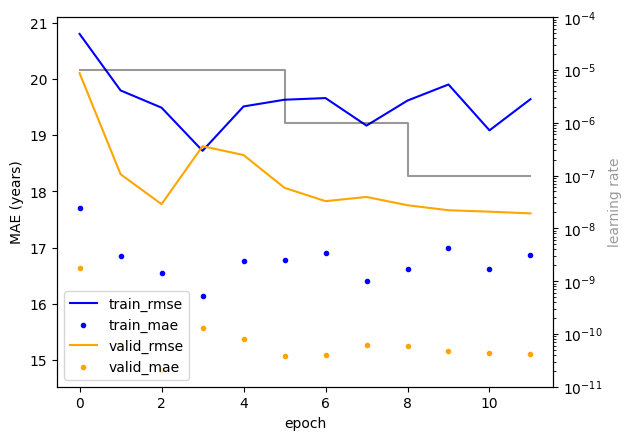

CPU times: user 1h 46min 20s, sys: 6min 15s, total: 1h 52min 35s
Wall time: 59min 24s


In [79]:
%%time
CSVPATH = '../1-starter-ecg-model/data/examscode15.csv'
H5PATH = '../1-starter-ecg-model/data/fullCODE15.h5'

torch.serialization.add_safe_globals([np.core.multiarray._reconstruct])
%run train.py $H5PATH $CSVPATH --batch_size 64 --epochs 10 --lr 1e-5 --min_lr 1e-10 --patience 2 --n_valid=100000 --dropout_rate 0.5 --cuda 1
%run plot_learning_curves.py ./model/history.csv